# Transformer-Based Summarization — T5
Abstractive summarization menggunakan `cahya/t5-base-indonesian-summarization-cased`.

**Objektif:**
1. **Summary quality** — ROUGE-1, ROUGE-2, ROUGE-L
2. **Contextual understanding** — contoh kualitatif
3. **Computational efficiency** — waktu inferensi

Input: `data_final.csv`

---
## Instalasi & Import

In [1]:
!pip install transformers sentencepiece rouge-score -q

In [2]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import T5Tokenizer, T5ForConditionalGeneration
from rouge_score import rouge_scorer
from tqdm import tqdm
tqdm.pandas()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_final.csv', encoding='utf-8-sig')

print(f'Dataset dimuat: {len(df)} baris, {len(df.columns)} kolom')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

Dataset dimuat: 12754 baris, 8 kolom
Kolom: ['global_id', 'id', 'title', 'category', 'article_text', 'body_word_count', 'lead_paragraph', 'lead_word_count']

Distribusi kategori:
category
sejarah     1986
arts        1975
artis       1971
kuliner     1958
tech        1728
biografi    1701
sains       1435


---
## 1. Preprocessing Teks

### 1a. Fungsi Pembersihan
**Identik dengan extractive approach** — hapus noise tanpa mengubah isi kalimat agar ROUGE tetap adil.

In [4]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)                      # hapus referensi [1], [2]
    text = re.sub(r'={2,}.*?={2,}', '', text)                # hapus == heading ==
    text = re.sub(r'http\S+|www\.\S+', '', text)             # hapus URL
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL) # hapus {{template}}
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)                         # rapikan spasi/newline
    return text.strip()

df['clean_text'] = df['article_text'].apply(clean_text)

print('Preprocessing selesai.')
print(f'\nContoh hasil (200 karakter):')
print(df['clean_text'].iloc[0][:200])

Preprocessing selesai.

Contoh hasil (200 karakter):
Keberadaan penyanyi cilik di Indonesia telah eksis sejak era 60-an. Pada saat itu sudah ada beberapa penyanyi anak-anak seperti Fenty Effendy, Anna Mathovani, atau Nenny Triana. Namun yang bisa dibila


### 1b. Re-filter Artikel Pendek

In [5]:
df['body_word_count'] = df['clean_text'].str.split().str.len()

MIN_WORDS = 100

before = len(df)
df = df[df['body_word_count'] >= MIN_WORDS].reset_index(drop=True)

print(f'Sebelum filter: {before} baris')
print(f'Sesudah filter: {len(df)} baris')
print(f'\nStatistik panjang artikel:')
print(df['body_word_count'].describe().round(0).to_string())

Sebelum filter: 12754 baris
Sesudah filter: 12693 baris

Statistik panjang artikel:
count    12693.0
mean       454.0
std        489.0
min        100.0
25%        183.0
50%        303.0
75%        540.0
max      12008.0


---
## 2. Load Model T5
T5 (Text-to-Text Transfer Transformer) dengan checkpoint `cahya/t5-base-indonesian-summarization-cased` — T5 base yang di-fine-tune pada data ringkasan bahasa Indonesia.

In [6]:
T5_MODEL_NAME = 'cahya/t5-base-indonesian-summarization-cased'

print(f'Memuat tokenizer dari {T5_MODEL_NAME}...')
tokenizer = T5Tokenizer.from_pretrained(T5_MODEL_NAME)

print('Memuat model...')
model = T5ForConditionalGeneration.from_pretrained(T5_MODEL_NAME).to(DEVICE)
model.eval()

print(f'Model siap | Parameter: {model.num_parameters():,}')

Memuat tokenizer dari cahya/t5-base-indonesian-summarization-cased...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/793k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Memuat model...


...

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model siap | Parameter: 296,926,464


---
## 3. Fungsi Summarization

### 3a. Fungsi Generik Summarize

In [7]:
MAX_INPUT_TOKENS  = 512
MAX_OUTPUT_TOKENS = 128
MIN_OUTPUT_TOKENS = 30

def summarize_transformer(text, prefix=''):
    input_text = prefix + text

    inputs = tokenizer(
        input_text,
        return_tensors='pt',
        max_length=MAX_INPUT_TOKENS,
        truncation=True,
        padding=False
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_OUTPUT_TOKENS,
            min_new_tokens=MIN_OUTPUT_TOKENS,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary.strip()

### 3b. Chunking untuk Artikel Panjang
Model transformer punya batasan panjang input (512 token). Artikel yang lebih panjang perlu dipecah dulu.

In [8]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def split_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.split()) >= 4]

MAX_SENTENCES_PER_CHUNK = 20

def chunk_sentences(sentences, max_per_chunk=MAX_SENTENCES_PER_CHUNK):
    return [sentences[i:i+max_per_chunk] for i in range(0, len(sentences), max_per_chunk)]

def summarize_with_chunking(text, prefix=''):
    sentences = split_sentences(text)

    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarize_transformer(text, prefix)

    chunks = chunk_sentences(sentences)
    chunk_summaries = []
    for chunk in chunks:
        chunk_text = ' '.join(chunk)
        chunk_summaries.append(summarize_transformer(chunk_text, prefix))

    combined = ' '.join(chunk_summaries)
    return summarize_transformer(combined, prefix)

print('=== Demo T5 ===')
print(summarize_with_chunking(df['clean_text'].iloc[0]))

=== Demo T5 ===
Keberadaan penyanyi cilik di Indonesia telah eksis sejak era 60-an. Pada saat itu sudah ada beberapa penyanyi anak-anak seperti Fenty Effendy, Anna Mathovani, atau Nenny Triana. Namun yang bisa dibilang pionir penyanyi ciliki yang paling tersohor dan masih eksis hingga saat ini adalah Adi Bing Slamet dan Ira Maya Sopha.


---
## 4. Generate Ringkasan untuk Seluruh Dataset

In [9]:
print('Generating ringkasan T5...')
start = time.time()

df['summary_t5'] = df['clean_text'].progress_apply(
    lambda x: summarize_with_chunking(x, prefix='')
)

time_t5 = time.time() - start
print(f'Selesai dalam {time_t5:.1f} detik ({time_t5/len(df):.2f} detik/artikel)')
print(f'\nContoh:')
print(f'JUDUL    : {df["title"].iloc[0]}')
print(f'RINGKASAN: {df["summary_t5"].iloc[0]}')

Generating ringkasan T5...


100%|██████████| 12693/12693 [9:52:32<00:00,  2.80s/it]

Selesai dalam 35552.9 detik (2.80 detik/artikel)

Contoh:
JUDUL    : Daftar artis cilik Indonesia
RINGKASAN: Keberadaan penyanyi cilik di Indonesia telah eksis sejak era 60-an. Pada saat itu sudah ada beberapa penyanyi anak-anak seperti Fenty Effendy, Anna Mathovani, atau Nenny Triana. Namun yang bisa dibilang pionir penyanyi ciliki yang paling tersohor dan masih eksis hingga saat ini adalah Adi Bing Slamet dan Ira Maya Sopha.


---
## 5. Simpan Hasil

In [10]:
output_cols = ['global_id', 'title', 'category', 'summary_t5', 'lead_paragraph', 'body_word_count']
hasil = df[[c for c in output_cols if c in df.columns]]

hasil.to_csv('hasil_summary_t5.csv', index=False, encoding='utf-8-sig')
print(f'Tersimpan: hasil_summary_t5.csv ({len(hasil)} baris)')

for i in range(min(3, len(hasil))):
    print(f'\n[{hasil["category"].iloc[i]}] {hasil["title"].iloc[i]}')
    print(f'  T5: {hasil["summary_t5"].iloc[i][:120]}...')

Tersimpan: hasil_summary_t5.csv (12693 baris)

[artis] Daftar artis cilik Indonesia
  T5: Keberadaan penyanyi cilik di Indonesia telah eksis sejak era 60-an. Pada saat itu sudah ada beberapa penyanyi anak-anak ...

[artis] A. Sarosa
  T5: Sejak kecil sudah senang main sandiwara kadang-kadang dengan kain ibunya sebagai layar. Ketika Fred Young mengadakan kon...

[artis] Onadio Leonardo
  T5: Onadio menjalin hubungan asmara berbeda agama dengan Beby Prisillia Gustiansyah-yang kini dikenal sebagai Beby Leonardo....


---
## 6. Evaluasi ROUGE
Metrik: ROUGE-1, ROUGE-2, ROUGE-L dengan ground truth `lead_paragraph`.

In [11]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

r1, r2, rl = [], [], []
for pred, ref in zip(df['summary_t5'], df['lead_paragraph']):
    s = scorer.score(str(ref), str(pred))
    r1.append(s['rouge1'].fmeasure)
    r2.append(s['rouge2'].fmeasure)
    rl.append(s['rougeL'].fmeasure)

rouge_t5 = (np.mean(r1), np.mean(r2), np.mean(rl))

print(f'{'Metrik':<10} | {'Skor':>8}')
print('-' * 22)
print(f'{'ROUGE-1':<10} | {rouge_t5[0]:>8.4f}')
print(f'{'ROUGE-2':<10} | {rouge_t5[1]:>8.4f}')
print(f'{'ROUGE-L':<10} | {rouge_t5[2]:>8.4f}')

Metrik     |     Skor
----------------------
ROUGE-1    |   0.1728
ROUGE-2    |   0.0416
ROUGE-L    |   0.1171


### 6a. ROUGE-L per Kategori

In [12]:
rows = []
for kategori in sorted(df['category'].unique()):
    sub = df[df['category'] == kategori]
    scores = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
              for pred, ref in zip(sub['summary_t5'], sub['lead_paragraph'])]
    rows.append({'kategori': kategori, 'jumlah': len(sub), 'rougeL': np.mean(scores)})

tabel = pd.DataFrame(rows).sort_values('rougeL', ascending=False)
print('ROUGE-L per kategori (T5):')
print(tabel.round(4).to_string(index=False))

ROUGE-L per kategori (T5):
kategori  jumlah  rougeL
 sejarah    1982  0.1234
biografi    1684  0.1228
 kuliner    1949  0.1182
    tech    1721  0.1165
    arts    1972  0.1155
   artis    1964  0.1141
   sains    1421  0.1074


### 6b. Computational Efficiency

In [13]:
print('Computational Efficiency — T5:')
print('=' * 45)
print(f'Total waktu   : {time_t5:.1f} detik')
print(f'Per artikel   : {time_t5/len(df):.2f} detik')
print(f'Jumlah artikel: {len(df)}')
print(f'Parameter     : {model.num_parameters():,}')

Computational Efficiency — T5:
Total waktu   : 35552.9 detik
Per artikel   : 2.80 detik
Jumlah artikel: 12693
Parameter     : 296,926,464


---
## 7. Visualisasi

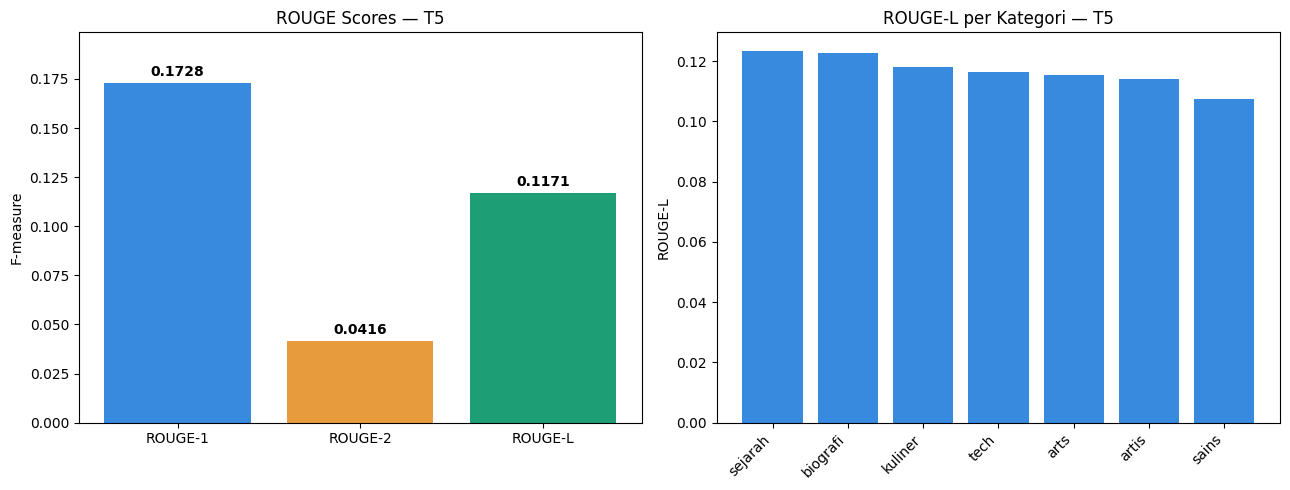

Grafik tersimpan: t5_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: ROUGE scores
ax = axes[0]
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
vals = list(rouge_t5)
bars = ax.bar(metrics, vals, color=['#378ADD', '#E89B3C', '#1D9E75'])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('ROUGE Scores — T5')
ax.set_ylabel('F-measure')
ax.set_ylim(0, max(vals) * 1.15)

# Plot 2: ROUGE-L per kategori
ax2 = axes[1]
xk = np.arange(len(tabel))
ax2.bar(xk, tabel['rougeL'], color='#378ADD')
ax2.set_xticks(xk)
ax2.set_xticklabels(tabel['kategori'], rotation=45, ha='right')
ax2.set_title('ROUGE-L per Kategori — T5')
ax2.set_ylabel('ROUGE-L')

plt.tight_layout()
plt.savefig('t5_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: t5_results.png')

---
## 8. Contoh Kualitatif

In [15]:
N_CONTOH = 3
sample_idx = df.sample(N_CONTOH, random_state=42).index

for i, idx in enumerate(sample_idx):
    row = df.loc[idx]
    print(f'{'='*70}')
    print(f'Artikel {i+1}: [{row["category"]}] {row["title"]}')
    print(f'Ground Truth (lead_paragraph):')
    print(f'  {str(row["lead_paragraph"])[:200]}...')
    print(f'T5:')
    print(f'  {row["summary_t5"][:200]}')
    print()

Artikel 1: [tech] Super Nintendo Entertainment System
Ground Truth (lead_paragraph):
  Super Nintendo Entertainment System, biasanya disingkat menjadi Super Nintendo, Super NES atau SNES adalah konsol permainan video rumah 16-bit yang dikembangkan oleh Nintendo yang dirilis pada tahun 1...
T5:
  Untuk bersaing dengan Family Computer yang populer di Jepang, NEC Home Electronics meluncurkan PC Engine pada tahun 1987, dan Sega mengikutinya dengan Mega Drive pada tahun 1988.

Artikel 2: [sejarah] Perjanjian Politik 17 Maret 1813
Ground Truth (lead_paragraph):
  Kontrak/Perjanjian Politik yang dibuat oleh BPH Notokusumo Paku Alam I dan Pemerintah Kerajaan Inggris pada tahun 1813, menurut catatan Soedarisman Poerwokoesoemo, adalah sebagai berikut:
"Perjanjian ...
T5:
  Orang Jawa sering menyebut Pemerintah Penjajah di Batavia dengan sebutan Gubermen. Apabila Kerajaan Belanda disebut Gubmen Belanda, sedangkan Kerajaan Inggris disebut Gubrmen Inggris. Sebutan tersebut

Artikel 3: [arts] Gamela